In [179]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from scipy.stats import ks_2samp
from uncertainties import unumpy as unp
from uncertainties import ufloat
from uncertainties.unumpy import log as ulog
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

from astropy.coordinates import SkyCoord
import astropy.units as u

import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import seaborn as sns

labelsize=12
palette = 'viridis'
font = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 14}
font_cb = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 12}


In [3]:
data = pd.read_csv('Dados\data.csv', index_col='Cluster')
df = pd.read_csv(r'Dados\results.csv', index_col='Cluster')
benchmark_subsample = pd.read_csv(r'Dados\benchmark_subsample.csv', index_col='Cluster')

In [356]:
data_sorted = data.sort_values(by='mass_system').reset_index(drop=True)

binarias = data_sorted[data_sorted.q>0]
singles = data_sorted[data_sorted.q==0]

n_div = 10

subconjuntos_all_systems = np.array_split(data_sorted, n_div)
subconjuntos_singles = np.array_split(singles, n_div)
subconjuntos_binarias = np.array_split(binarias, n_div)

# Listas para armazenar os resultados
masses = []
mass_errors = []

radius_rh = []
radius_rh_errors = []

mean_q = []

binary_system_masses = []
single_system_masses = []

binary_system_r_rh = []
single_system_r_rh = []

# Loop por grupo
for i in range(0, n_div):
    
    # _________________Massa média com incerteza__________________________________
    
    #All systems
    mass_values = subconjuntos_all_systems[i].mass_system
    mass_mean = mass_values.mean()
    masses.append(mass_mean)
    mass_errors.append(np.std(mass_values)/np.sqrt(len(mass_values)))
    
    #Singles
    mass_values = subconjuntos_singles[i].mass_system
    mass_mean = mass_values.mean()
    single_system_masses.append(mass_mean)    
    
    #Binaries
    
    mass_values = subconjuntos_binarias[i].mass_system
    mass_mean = mass_values.mean()
    binary_system_masses.append(mass_mean) 
    

    #____________________ r/rh médio com incerteza __________________________________________
    
    # All systems
    rrh_values = subconjuntos_all_systems[i]['r/rh']
    rrh_mean = rrh_values.mean()
    radius_rh.append(rrh_mean)
    radius_rh_errors.append(np.std(rrh_values)/np.sqrt(len(rrh_values)))

    # Singles
    
    rrh_values = unumpy.uarray(subconjuntos_singles[i]['r/rh'], subconjuntos_singles[i]['e_r/rh'])
    rrh_mean = rrh_values.mean()
    single_system_r_rh.append(rrh_mean.nominal_value)

    
    
    # Binaries
    
    rrh_values = unumpy.uarray(subconjuntos_binarias[i]['r/rh'], subconjuntos_binarias[i]['e_r/rh'])
    rrh_mean = rrh_values.mean()
    binary_system_r_rh.append(rrh_mean.nominal_value)
    
    
    # Razão de massa média dos binários
    mean_q.append(subconjuntos_all_systems[i][subconjuntos_all_systems[i].q>0]['q'].mean())

# Converte listas para arrays numpy
masses = np.array(masses)
mass_errors = np.array(mass_errors)

radius_rh = np.array(radius_rh)
radius_rh_errors = np.array(radius_rh_errors)

mean_q = np.array(mean_q)

binary_system_masses = np.array(binary_system_masses)
single_system_masses = np.array(single_system_masses)

binary_system_r_rh = np.array(binary_system_r_rh)
single_system_r_rh = np.array(single_system_r_rh)


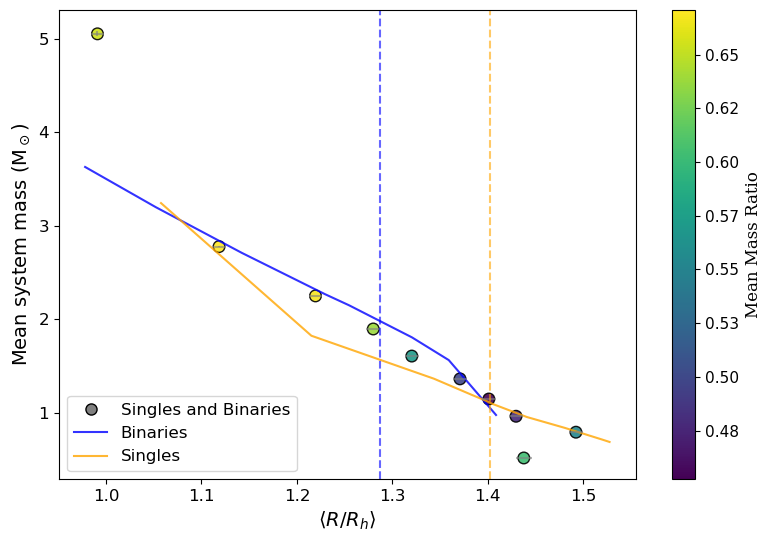

In [362]:
fig, ax = plt.subplots(figsize=(8, 6))

# Suavizações LOWESS
y_bin = sm.nonparametric.lowess(binary_system_masses, binary_system_r_rh, frac=0.5)
ax.plot(y_bin[:, 0], y_bin[:, 1], color='blue', alpha=0.8, label='Binaries')

y_sing = sm.nonparametric.lowess(single_system_masses, single_system_r_rh, frac=0.5)
ax.plot(y_sing[:, 0], y_sing[:, 1], color='orange', alpha=0.8, label='Singles')


plt.scatter(radius_rh, masses, c=mean_q, cmap='viridis', s=70, edgecolor='k', alpha=0.9,)
plt.errorbar(radius_rh, masses, xerr = radius_rh_errors, yerr=mass_errors, fmt='none', ecolor='gray', alpha=0.6)

#Cria ponto para a legenda
scatter_proxy = mlines.Line2D(
    [], [], linestyle='None', marker='o', color='k', markerfacecolor='gray', 
    markersize=8, label='Singles and Binaries')


# Linhas de mediana
ax.axvline(np.median(single_system_r_rh), ls='--', color='orange', alpha=0.6)
ax.axvline(np.median(binary_system_r_rh), ls='--', color='blue', alpha=0.6)

# Colorbar
norm = plt.Normalize(min(mean_q), max(mean_q))
smappable = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
smappable.set_array([])
cbar = plt.colorbar(smappable)
cbar.set_label('Mean Mass Ratio', fontdict=font_cb)
cbar.ax.tick_params(labelsize=11)
cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

# Labels
ax.set_xlabel(r'$\langle R/R_h \rangle$', fontdict=font)
ax.set_ylabel(r'$\mathrm{Mean \  system \ mass \ (M_\odot)}$', fontdict=font)
ax.tick_params(axis='both', labelsize=labelsize)

# Legenda
ax.legend(handles=[scatter_proxy] + ax.get_legend_handles_labels()[0], fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


# Tempo de relaxamento

In [56]:
resultados =pd.DataFrame(index=df.index)

resultados[r'$f_b$'] = unumpy.uarray(df['bin_frac'], df['er_bin_frac'])
resultados[r'$t_{relax}$ [Myr]'] = unumpy.uarray(df['t_relax']/1e6, df['er_t_relax']/1e6)
resultados[r'$\tau$'] = unumpy.uarray(df['tau'], df['er_tau'])
resultados[r'$R_h$'] = df['rh']
def format_ufloat(x):
    return f"{x.nominal_value:.2f} ± {x.std_dev:.2f}"
tabela_formatada = resultados.copy()

for col in resultados.columns:
    if resultados[col].dtype == 'O':  # coluna com ufloat
        tabela_formatada[col] = resultados[col].apply(format_ufloat)
    else:
        tabela_formatada[col] = resultados[col].map("{:.2f}".format)
        
latex = tabela_formatada.to_latex(index=True, escape=False)


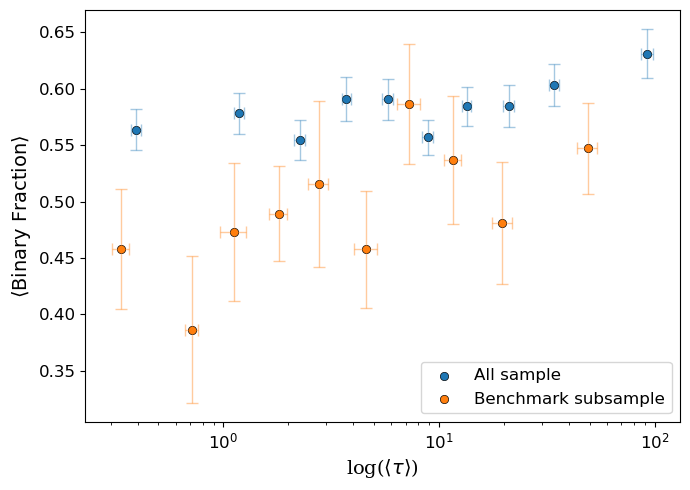

In [363]:
subconjuntos = np.array_split(df.sort_values(by='tau'), 10)
subconjuntos_benchmark = np.array_split(benchmark_subsample.sort_values(by='tau'), 10)

tau_mean = []
tau_benchmark_mean = []
bin_frac_mean = []
bin_frac_benchmark_mean = []

for i in range(len(subconjuntos)):
    tau_vals = subconjuntos[i]["tau"].values
    tau_errs = subconjuntos[i]["e_tau"].values
    tau_ufloats = unumpy.uarray(tau_vals, tau_errs)
    tau_mean.append((tau_ufloats).mean())

    tau_b_vals = subconjuntos_benchmark[i]["tau"].values
    tau_b_errs = subconjuntos_benchmark[i]["e_tau"].values
    tau_b_ufloats = unumpy.uarray(tau_b_vals, tau_b_errs)
    tau_benchmark_mean.append((tau_b_ufloats).mean())

    # bin_frac y er_bin_frac
    bf_vals = subconjuntos[i]["bin_frac"].values
    bf_errs = subconjuntos[i]["e_bin_frac"].values
    bf_ufloats = unumpy.uarray(bf_vals, bf_errs)
    bin_frac_mean.append((bf_ufloats).mean())

    bf_b_vals = subconjuntos_benchmark[i]["bin_frac"].values
    bf_b_errs = subconjuntos_benchmark[i]["e_bin_frac"].values
    bf_b_ufloats = unumpy.uarray(bf_b_vals, bf_b_errs)
    bin_frac_benchmark_mean.append((bf_b_ufloats).mean())

tau_mean = np.array(tau_mean)
tau_benchmark_mean = np.array(tau_benchmark_mean)
bin_frac_mean = np.array(bin_frac_mean)
bin_frac_benchmark_mean = np.array(bin_frac_benchmark_mean)

x = unumpy.nominal_values(tau_mean)
y = unumpy.nominal_values(bin_frac_mean)
xerr = unumpy.std_devs(tau_mean)
yerr = unumpy.std_devs(bin_frac_mean)

x_bench = unumpy.nominal_values(tau_benchmark_mean)
y_bench = unumpy.nominal_values(bin_frac_benchmark_mean)
xerr_bench = unumpy.std_devs(tau_benchmark_mean)
yerr_bench = unumpy.std_devs(bin_frac_benchmark_mean)

fig, ax = plt.subplots(figsize=(7, 5))

# Scatterplot para todos os dados
sns.scatterplot(x=x, y=y, ax=ax, label='All sample', color='tab:blue', edgecolor='k',)
ax.errorbar(x, y,xerr=xerr, yerr=yerr,fmt='none',ecolor='tab:blue',alpha=0.4,capsize=4,elinewidth=1,)

# Scatterplot para benchmark
sns.scatterplot(x=x_bench, y=y_bench,ax=ax,label='Benchmark subsample',color='tab:orange',edgecolor='k',)
ax.errorbar(x_bench, y_bench,xerr=xerr_bench, yerr=yerr_bench,fmt='none',ecolor='tab:orange',alpha=0.4,capsize=4,elinewidth=1,)

# Escala logarítmica no eixo x
ax.set_xscale('log')

ax.set_xlabel(r"log($\langle \tau \rangle$)", fontdict=font)
ax.set_ylabel(r"$\langle \mathrm{Binary\ Fraction} \rangle$", fontdict=font)
ax.tick_params(axis='both', labelsize=labelsize)


ax.legend(loc='lower right', fontsize=12,)

plt.tight_layout()
#plt.savefig('fb_tau2.png', dpi=300)
plt.show()


In [ ]:
c = 4 * np.pi / 3
V = c*df['rh']**3
density = df['n_members']/V
q_mean = []
for cluster in df.index:
    q_mean.append(data[data.q>0].loc[cluster, 'q'].mean())
    
sns.scatterplot(x=density,y=q_mean,)
plt.xscale('log')
plt.xlabel(r'$\rho_\star$ ($\star/pc^3$)', fontdict=font)
plt.ylabel(r"$\langle \mathrm{q} \rangle$", fontdict=font)

plt.show()

In [ ]:
sns.scatterplot(x=density,y=df.bin_frac)
plt.xscale('log')
plt.xlabel(r'$\rho_\star$ ($\mathrm{stars/pc^3}$)', fontdict=font)
plt.ylabel(r"Binary fraction", fontdict=font)

plt.show()